In [4]:
# RNN:
!pip install tensorflow

import numpy as np
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical

max_features = 10000
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=max_features)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))


max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

num_classes = 46
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("Number of classes:", num_classes)

model = Sequential()
model.add(Embedding(input_dim=max_features, output_dim=32, input_length=max_len))
model.add(SimpleRNN(64))
model.add(Dense(num_classes, activation='softmax'))


model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=60,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

Training samples: 8982
Test samples: 2246
x_train shape: (8982, 200)
x_test shape: (2246, 200)
Number of classes: 46


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.3090 - loss: 2.7945 - val_accuracy: 0.2371 - val_loss: 2.8426
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4118 - loss: 2.2456 - val_accuracy: 0.4491 - val_loss: 2.1737
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4635 - loss: 2.0387 - val_accuracy: 0.4012 - val_loss: 2.1793
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5150 - loss: 1.8631 - val_accuracy: 0.4869 - val_loss: 1.8983
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5852 - loss: 1.6489 - val_accuracy: 0.5109 - val_loss: 1.8308
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6422 - loss: 1.4597 - val_accuracy: 0.4597 - val_loss: 1.9201
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6921 - loss: 1.2825 - val_accuracy: 0.5398 - val_loss: 1.7739
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7172 - loss: 1.1235 - val_accu

In [7]:
# LSTM
!pip install tensorflow

import numpy as np
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

max_features = 10000
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=max_features)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

num_classes = 46
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("Number of classes:", num_classes)

model = Sequential()


model.add(Embedding(input_dim=max_features, output_dim=64, input_length=max_len))

model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))


model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=71,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

Training samples: 8982
Test samples: 2246
x_train shape: (8982, 200)
x_test shape: (2246, 200)
Number of classes: 46


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 77s 719ms/step - accuracy: 0.3464 - loss: 2.6626 - val_accuracy: 0.3450 - val_loss: 2.4042
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 73s 717ms/step - accuracy: 0.4372 - loss: 2.2057 - val_accuracy: 0.4886 - val_loss: 2.0468
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 73s 720ms/step - accuracy: 0.4937 - loss: 1.9881 - val_accuracy: 0.5086 - val_loss: 1.9050
Epoch 4/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 73s 713ms/step - accuracy: 0.5424 - loss: 1.7604 - val_accuracy: 0.5314 - val_loss: 1.9436
Epoch 5/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 73s 711ms/step - accuracy: 0.5699 - loss: 1.6816 - val_accuracy: 0.5810 - val_loss: 1.6474
Epoch 6/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 82s 712ms/step - accuracy: 0.6004 - loss: 1.5662 - val_accuracy: 0.5965 - val_loss: 1.5816
Epoch 7/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 71s 699ms/step - accuracy: 0.6248 - loss: 1.4825 - val_accuracy: 0.6155 - val_loss: 1.5658
Epoch 8/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 82s 697ms/step - accuracy: 0.6419 - loss: 1

In [8]:
# GRU
!pip install tensorflow

import numpy as np
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.utils import to_categorical

max_features = 10000
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=max_features)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

num_classes = 46
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("Number of classes:", num_classes)

model = Sequential()

model.add(Embedding(input_dim=max_features, output_dim=64, input_length=max_len))


model.add(GRU(64, dropout=0.2, recurrent_dropout=0.2))

model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


Training samples: 8982
Test samples: 2246
x_train shape: (8982, 200)
x_test shape: (2246, 200)
Number of classes: 46


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 76s 642ms/step - accuracy: 0.3578 - loss: 2.5650 - val_accuracy: 0.4218 - val_loss: 2.0517
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 73s 647ms/step - accuracy: 0.4757 - loss: 1.9194 - val_accuracy: 0.5225 - val_loss: 1.8099
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 72s 636ms/step - accuracy: 0.5333 - loss: 1.7334 - val_accuracy: 0.5337 - val_loss: 1.7486
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 71s 631ms/step - accuracy: 0.5606 - loss: 1.6516 - val_accuracy: 0.5665 - val_loss: 1.7130
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 71s 630ms/step - accuracy: 0.5847 - loss: 1.5765 - val_accuracy: 0.5682 - val_loss: 1.6971
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 84s 649ms/step - accuracy: 0.6051 - loss: 1.5122 - val_accuracy: 0.5815 - val_loss: 1.6711
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 72s 635ms/step - accuracy: 0.6251 - loss: 1.4450 - val_accuracy: 0.5671 - val_loss: 1.6843
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 75s 660ms/step - accuracy: 0.6363 - loss: 1

In [ ]:
# BiLSTM
!pip install tensorflow

import numpy as np
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical

max_features = 10000
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=max_features)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

num_classes = 46
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("Number of classes:", num_classes)

model = Sequential()

model.add(Embedding(input_dim=max_features, output_dim=64, input_length=max_len))


model.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)))


model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


Training samples: 8982
Test samples: 2246
x_train shape: (8982, 200)
x_test shape: (2246, 200)
Number of classes: 46


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.4534 - loss: 2.3021 - val_accuracy: 0.5159 - val_loss: 1.9656
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.5104 - loss: 1.9814 - val_accuracy: 0.5270 - val_loss: 1.8759
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.5520 - loss: 1.7981 - val_accuracy: 0.5787 - val_loss: 1.7166
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.5843 - loss: 1.6441 - val_accuracy: 0.5765 - val_loss: 1.6405
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.6132 - loss: 1.5369 - val_accuracy: 0.5927 - val_loss: 1.5955
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 237ms/step - accuracy: 0.5962 - loss: 1.6269
Test Accuracy: 0.596170961856842


LSTM:0.65, 15 epochs
GRU:0.59, 10 epochs
RNN: 0.52, 10 epochs
BILSTM:0.59, 5 epochs

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: (60000, 28, 28, 1)
Test samples: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8213 - loss: 0.4837 - val_accuracy: 0.8674 - val_loss: 0.3586
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8852 - loss: 0.3106 - val_accuracy: 0.8812 - val_loss: 0.3327
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9018 - loss: 0.2634 - val_accuracy: 0.8977 - val_loss: 0.2853
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9151 - loss: 0.2283 - val_accuracy: 0.9051 - val_loss: 0.2662
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9243 - loss: 0.2044 - val_accuracy: 0.9019 - val_loss: 0.2718
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9330 - loss: 0.1795 - val_accuracy: 0.9102 - val_loss: 0.2611
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9391 - loss: 0.1614 - val_accuracy: 0.9078 - val_loss: 0.2766
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9461 - loss: 0.1421 -

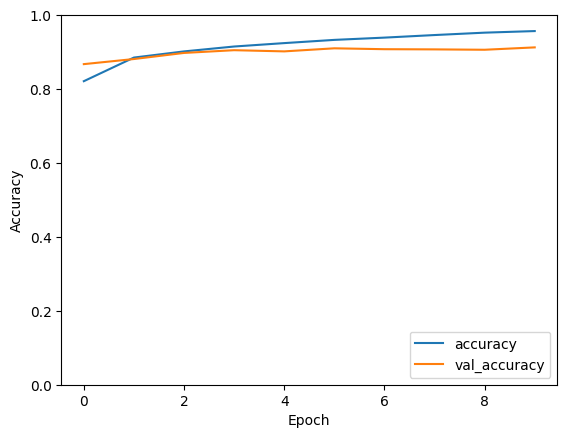

313/313 - 1s - 3ms/step - accuracy: 0.9127 - loss: 0.2981

Test accuracy: 0.9126999974250793


In [ ]:
# CNN
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()


train_images, test_images = train_images / 255.0, test_images / 255.0

train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

print("Training samples:", train_images.shape)
print("Test samples:", test_images.shape)


model = models.Sequential()


model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


model.add(layers.Conv2D(128, (3, 3), activation='relu'))


model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc}')
